# DoDick — тесты и графики

Стартовый ноутбук. Работает с **локальной копией** серверной БД (живую базу не трогаем).

**1. Забрать свежую копию БД с сервера** (PowerShell):
```
scp -i C:\Users\savkost\.ssh\digitalocean root@167.172.185.88:/opt/running-bot/running_bot.db D:/running-bot/data/running_bot.db
```

**2. Зависимости** (один раз): `pip install pandas matplotlib`

Папки `data/` и `.ipynb_checkpoints/` в git не попадают; сами ноутбуки — коммитятся.

Вернёт DataFrame с колонкой name — все таблицы базы
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)

глянуть структуру конкретной таблицы
pd.read_sql("PRAGMA table_info(unified_cache)", conn)

число строк по всем таблицам сразу
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)["name"]
pd.DataFrame({t: [pd.read_sql(f"SELECT COUNT(*) c FROM {t}", conn)["c"][0]] for t in tables}).T

In [1]:
!scp -i C:\Users\savkost\.ssh\digitalocean root@167.172.185.88:/opt/running-bot/running_bot.db D:/running-bot/data/running_bot.db

In [2]:
from IPython.display import HTML, display
display(HTML("""
<style>
/* классический Notebook 6 */
.container { width: 80% !important; }
/* Notebook 7 / JupyterLab */
:root { --jp-notebook-max-width: 80vw !important; }
.jp-Notebook .jp-Cell { max-width: 80vw !important; }
</style>
"""))

In [3]:
import sys
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# модули бота доступны как обычные импорты: import data_normalizer и т.д.
sys.path.insert(0, "../src")

DB = "../data/running_bot.db"
conn = sqlite3.connect(DB)
print("таблицы:", [r[0] for r in conn.execute(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")])

таблицы: ['athlete_cache', 'bot_settings', 'feedback', 'garmin_recovery_cache', 'last_recommendation', 'mornings', 'raw_service_data', 'recommendation_ratings', 'sqlite_sequence', 'unified_cache', 'user_activity', 'user_preferences', 'user_profile', 'user_tokens', 'users', 'workout_analysis', 'workout_notifications', 'workout_templates']


In [4]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)

,name
0,athlete_cache
1,bot_settings
2,feedback
3,garmin_recovery_cache
4,last_recommendation
5,mornings
6,raw_service_data
7,recommendation_ratings
8,sqlite_sequence
9,unified_cache


In [5]:
# Пример 1: юзеры
pd.read_sql("SELECT * FROM users LIMIT 2", conn)

,id,telegram_id,name,username,created_at
0,2,273726778,Anton,t_savkost,2026-05-17 17:25:56
1,3,2028713254,Rename Me,Un_nameme,2026-05-26 09:26:07


In [6]:
# Пример 1: юзеры
pd.read_sql("SELECT * FROM unified_cache", conn)

,user_id,unified_json,sources,updated_at,morning_caught,morning_date,morning_tr,morning_bb,morning_hrv,morning_rhr,morning_sleep_h,morning_wake_at,morning_snapshot_at
0,2,"{""s3_vo2max"": 47.9, ""s3_lactate_threshold_pace...","garmin,strava,whoop",2026-06-15 03:14:40,1,2026-06-15,54.0,77.0,44.0,45.0,6.50,2026-06-15T06:10:21,2026-06-15T03:14:40.123533+00:00
1,4,"{""s3_vo2max"": null, ""s3_lactate_threshold_pace...",garmin,2026-06-15 03:14:44,1,2026-06-15,1.0,31.0,38.0,47.0,5.27,2026-06-15T05:55:23,2026-06-15T03:14:44.130061+00:00
2,5,"{""s3_vo2max"": 51.1, ""s3_lactate_threshold_pace...",strava,2026-06-14 04:15:46,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6,"{""s3_vo2max"": 53.1, ""s3_lactate_threshold_pace...","coros,strava",2026-06-15 05:44:38,1,2026-06-15,0.0,87.0,99.0,43.0,NaN,NaN,2026-06-15T05:44:38.523705+00:00
4,7,"{""s3_vo2max"": null, ""s3_lactate_threshold_pace...",polar,2026-06-14 04:16:13,1,2026-06-12,NaN,NaN,59.0,62.0,NaN,2026-06-12T05:35:07.096+03:00,2026-06-12T03:07:41.221250+00:00
5,8,"{""s3_vo2max"": null, ""s3_lactate_threshold_pace...",garmin,2026-06-15 05:14:43,1,2026-06-15,48.0,83.0,55.0,54.0,7.52,2026-06-15T07:59:56,2026-06-15T05:14:43.491950+00:00
6,9,"{""s3_vo2max"": null, ""s3_lactate_threshold_pace...",garmin,2026-06-14 04:16:17,1,2026-06-07,NaN,NaN,NaN,NaN,NaN,NaN,2026-06-07T15:39:17.514627+00:00
7,13,"{""s3_vo2max"": null, ""s3_lactate_threshold_pace...",garmin,2026-06-15 04:59:49,1,2026-06-15,40.0,74.0,49.0,42.0,5.52,2026-06-15T06:56:45,2026-06-15T04:59:49.663837+00:00
8,17,"{""s3_vo2max"": 56.2, ""s3_lactate_threshold_pace...",coros,2026-06-14 05:10:17,1,2026-06-14,91.0,95.0,59.0,51.0,NaN,NaN,2026-06-14T05:10:17.380504+00:00
9,20,"{""s3_vo2max"": 57.2, ""s3_lactate_threshold_pace...",coros,2026-06-14 04:16:40,1,2026-06-13,27.0,100.0,42.0,43.0,NaN,NaN,2026-06-13T05:53:11.129115+00:00


In [7]:
# Пример 1: юзеры
pd.read_sql("SELECT * FROM mornings where user_id = 2", conn)

,user_id,date,sources,morning_caught,morning_tr,morning_bb,morning_hrv,morning_rhr,morning_sleep_h,morning_wake_at,morning_snapshot_at
0,2,2026-06-14,"garmin,strava,whoop",1,64,96,47.0,44,7.7,2026-06-14T07:21:03,2026-06-14T04:25:06.571555+00:00
1,2,2026-06-15,"garmin,strava,whoop",1,54,77,44.0,45,6.5,2026-06-15T06:10:21,2026-06-15T03:14:40.123533+00:00


In [10]:
# Пример 1: юзеры
pd.read_sql("SELECT * FROM workout_templates", conn)

,workout_date,group_number,wtype,workout_json,created_at


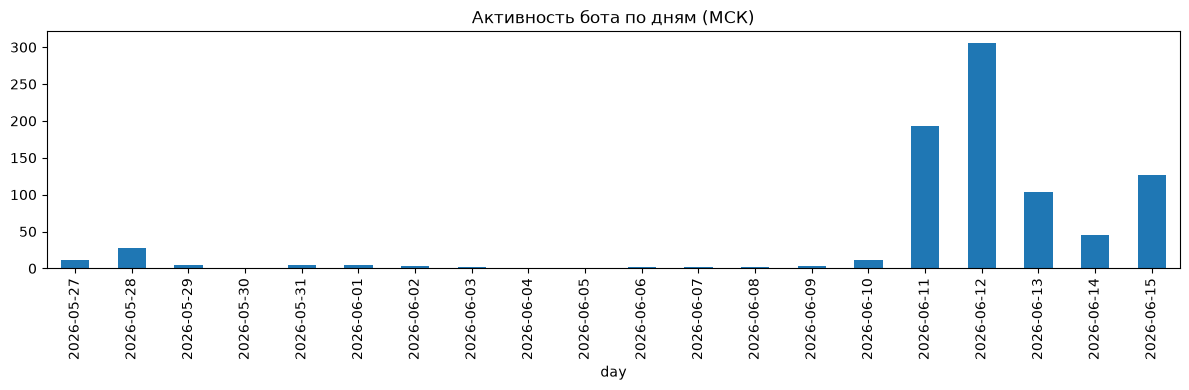

In [8]:
# Пример 2: график активности по дням (МСК = created_at + 3ч)
df = pd.read_sql(
    "SELECT date(created_at, '+3 hours') AS day, COUNT(*) AS actions "
    "FROM user_activity GROUP BY day ORDER BY day", conn)
df.plot(x="day", y="actions", kind="bar", figsize=(12, 4), legend=False)
plt.title("Активность бота по дням (МСК)")
plt.tight_layout()
plt.show()

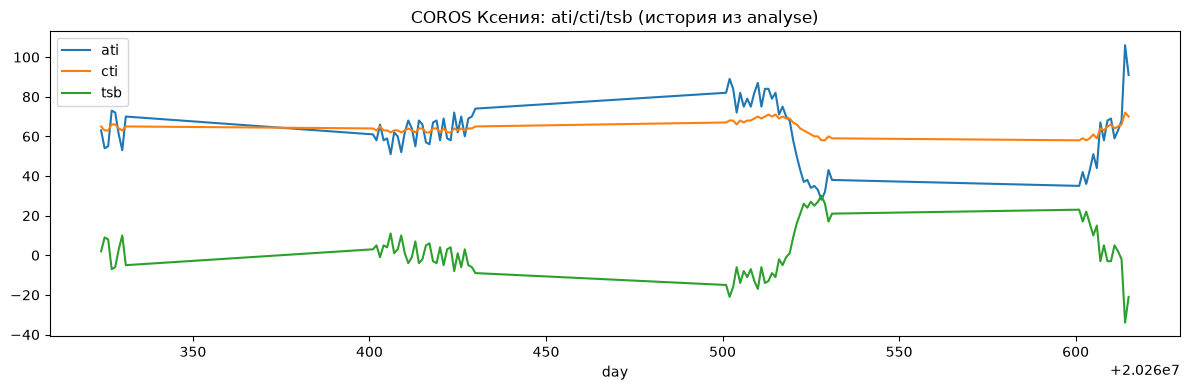

In [9]:
# Пример 3: расчётный TR COROS — формула на истории ati/cti из сырья
import json
row = conn.execute(
    "SELECT raw_json FROM raw_service_data WHERE user_id=6 AND service='coros'").fetchone()
if row:
    raw = json.loads(row[0])
    days = ((raw.get("analyse") or {}).get("data") or {}).get("dayList") or []
    df = pd.DataFrame([{"day": d.get("happenDay"), "ati": d.get("ati"), "cti": d.get("cti")}
                       for d in days if isinstance(d, dict)]).dropna()
    df["tsb"] = df["cti"] - df["ati"]
    df["base"] = ((df["tsb"] + 20) / 0.4).clip(0, 100)
    df.plot(x="day", y=["ati", "cti", "tsb"], figsize=(12, 4))
    plt.title("COROS Ксения: ati/cti/tsb (история из analyse)")
    plt.tight_layout()
    plt.show()
else:
    print("нет сырья coros для user_id=6 — забери свежую копию БД")

 # аналитика

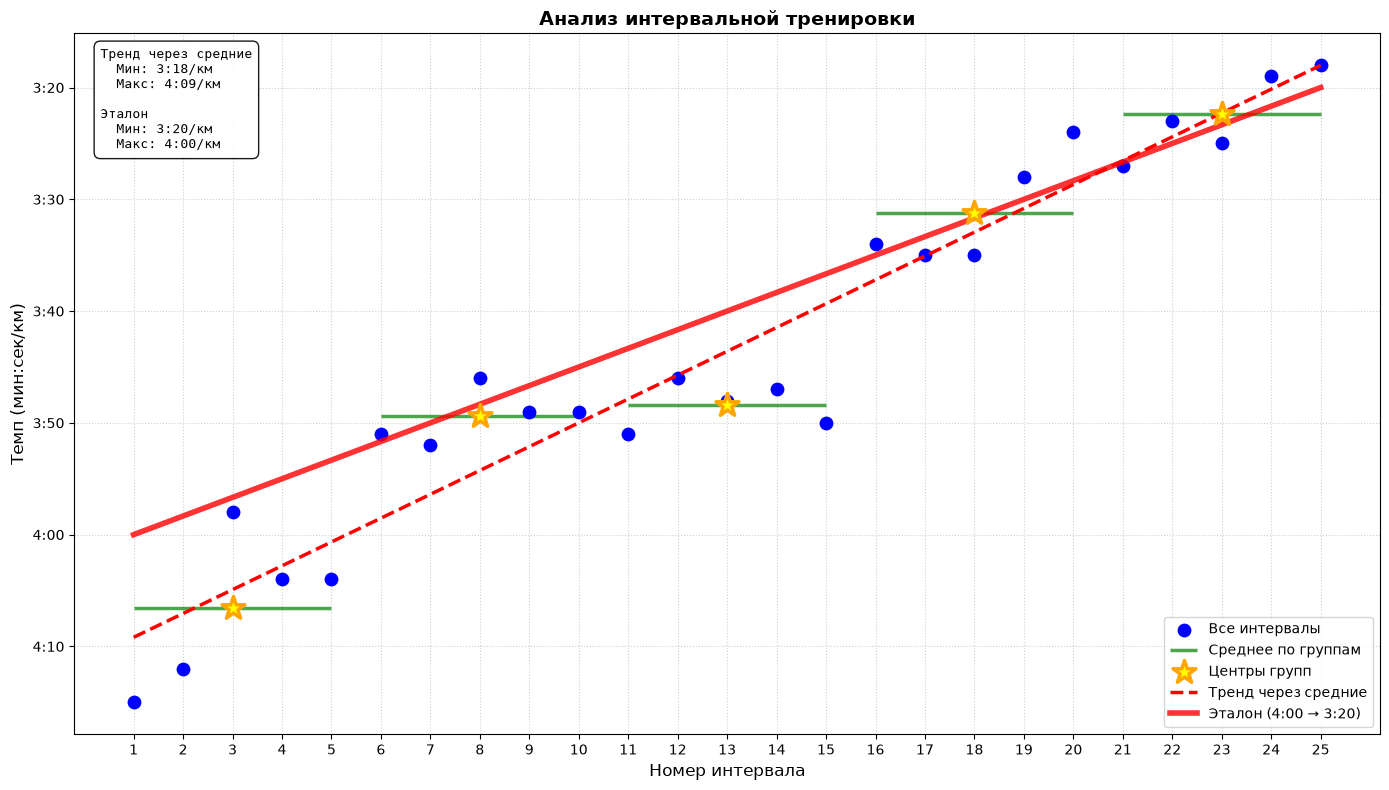

Средние значения по группам:
  Группа 1 (интервалы 1-5): 4:06/км
  Группа 2 (интервалы 6-10): 3:49/км
  Группа 3 (интервалы 11-15): 3:48/км
  Группа 4 (интервалы 16-20): 3:31/км
  Группа 5 (интервалы 21-25): 3:22/км

Тренд через средние: наклон = -2.132 сек/интервал
Тренд через средние: Мин=3:18/км, Макс=4:09/км
Эталон: Мин=3:20/км, Макс=4:00/км


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from matplotlib.ticker import FuncFormatter

# Данные из таблицы
intervals = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 
                      16, 17, 18, 19, 20, 21, 22, 23, 24, 25])

paces_raw = ['4:15', '4:12', '3:58', '4:04', '4:04', 
             '3:51', '3:52', '3:46', '3:49', '3:49',
             '3:51', '3:46', '3:48', '3:47', '3:50',
             '3:34', '3:35', '3:35', '3:28', '3:24',
             '3:27', '3:23', '3:25', '3:19', '3:18']

# Функции конвертации
def pace_to_seconds(pace_str):
    m, s = map(int, pace_str.split(':'))
    return m * 60 + s

def seconds_to_pace(seconds):
    m = int(seconds // 60)
    s = int(seconds % 60)
    return f"{m}:{s:02d}"

paces_sec = np.array([pace_to_seconds(p) for p in paces_raw])

# Разбиение на 5 групп и расчет средних
group_averages = []
group_centers = []
group_ranges = []
for i in range(0, 25, 5):
    group = paces_sec[i:i+5]
    avg = np.mean(group)
    group_averages.append(avg)
    center = i + 3
    group_centers.append(center)
    group_ranges.append((i+1, i+5))

group_averages = np.array(group_averages)
group_centers = np.array(group_centers)

# Линия тренда через средние значения групп
slope, intercept, r_value, p_value, std_err = stats.linregress(group_centers, group_averages)
trend_through_groups = slope * intervals + intercept

# Эталонная линия: от 4:00 (240 сек) для x=1 до 3:20 (200 сек) для x=25
etalon_start = 240  # 4:00
etalon_end = 200    # 3:20
etalon_slope = (etalon_end - etalon_start) / (25 - 1)
etalon_intercept = etalon_start - etalon_slope * 1
etalon_line = etalon_slope * intervals + etalon_intercept

# Форматтер для оси Y
def pace_formatter(x, pos):
    if x <= 0: return ""
    return seconds_to_pace(x)

# Построение графика
fig, ax = plt.subplots(figsize=(14, 8))

# Все 25 точек
ax.scatter(intervals, paces_sec, color='blue', s=80, zorder=3, label='Все интервалы')

# Горизонтальные линии для каждой группы
for i, (avg, (start, end)) in enumerate(zip(group_averages, group_ranges)):
    ax.hlines(y=avg, xmin=start, xmax=end, color='green', linewidth=2.5, 
              alpha=0.7, zorder=2, label='Среднее по группам' if i==0 else "")

# Желтые звезды - средние по группам
ax.scatter(group_centers, group_averages, color='yellow', s=300, zorder=5, 
           marker='*', edgecolors='orange', linewidths=2.5, label='Центры групп')

# Линия тренда через средние
ax.plot(intervals, trend_through_groups, 'r--', linewidth=2.5, zorder=4, 
        label=f'Тренд через средние')

# Эталонная линия (красная, жирная)
ax.plot(intervals, etalon_line, color='red', linewidth=4, linestyle='-', zorder=4, 
        label='Эталон (4:00 → 3:20)', alpha=0.8)

# Инверсия оси Y (быстрый темп вверху)
ax.invert_yaxis()

# Настройка осей
ax.set_xlabel('Номер интервала', fontsize=12)
ax.set_ylabel('Темп (мин:сек/км)', fontsize=12)
ax.set_title('Анализ интервальной тренировки', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(FuncFormatter(pace_formatter))

# Сетка и все 25 точек на оси X
ax.set_xticks(intervals)
ax.grid(True, linestyle=':', alpha=0.6)

# Легенда в левый верхний угол с мин/макс
trend_min = seconds_to_pace(min(trend_through_groups))
trend_max = seconds_to_pace(max(trend_through_groups))
etalon_min = seconds_to_pace(min(etalon_line))
etalon_max = seconds_to_pace(max(etalon_line))

legend_text = (f'Тренд через средние\n'
               f'  Мин: {trend_min}/км\n'
               f'  Макс: {trend_max}/км\n\n'
               f'Эталон\n'
               f'  Мин: {etalon_min}/км\n'
               f'  Макс: {etalon_max}/км')

ax.text(0.02, 0.98, legend_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.9),
        fontfamily='monospace')

# Основная легенда
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

# Вывод статистики
print("Средние значения по группам:")
for i, (center, avg, (start, end)) in enumerate(zip(group_centers, group_averages, group_ranges)):
    print(f"  Группа {i+1} (интервалы {start}-{end}): {seconds_to_pace(avg)}/км")

print(f"\nТренд через средние: наклон = {slope:.3f} сек/интервал")
print(f"Тренд через средние: Мин={trend_min}/км, Макс={trend_max}/км")
print(f"Эталон: Мин={etalon_min}/км, Макс={etalon_max}/км")

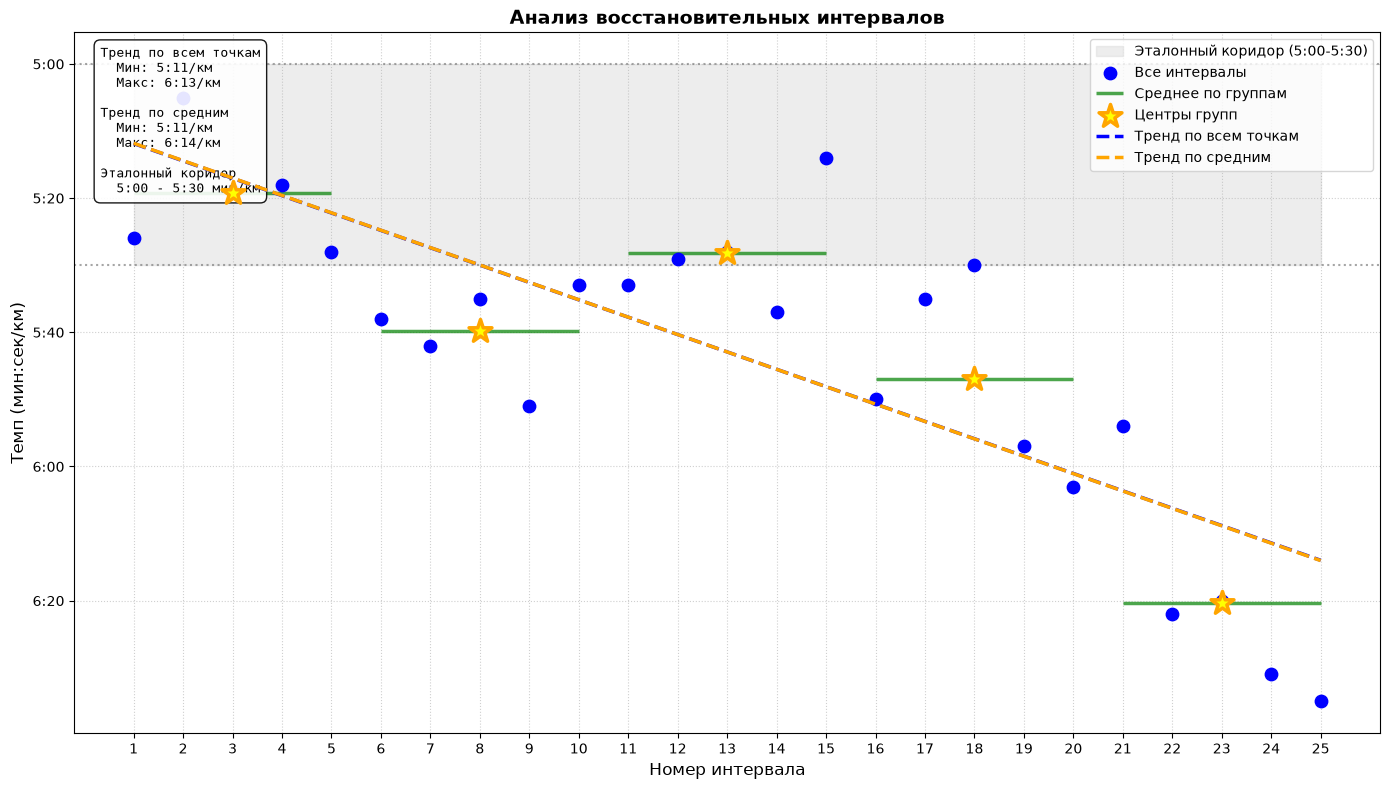

=== СТАТИСТИКА ===

Тренд по всем точкам:
  Мин: 5:11/км
  Макс: 6:13/км
  Наклон: 2.588 сек/интервал

Тренд по средним:
  Мин: 5:11/км
  Макс: 6:14/км
  Наклон: 2.592 сек/интервал

Средние по группам:
  Группа 1 (интервалы 1-5): 5:19/км
  Группа 2 (интервалы 6-10): 5:39/км
  Группа 3 (интервалы 11-15): 5:28/км
  Группа 4 (интервалы 16-20): 5:47/км
  Группа 5 (интервалы 21-25): 6:20/км


In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from matplotlib.ticker import FuncFormatter

# Данные из таблицы восстановления (24 точки + 25-я добавлена)
intervals = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 
                      16, 17, 18, 19, 20, 21, 22, 23, 24, 25])

paces_raw = ['5:26', '5:05', '5:19', '5:18', '5:28', 
             '5:38', '5:42', '5:35', '5:51', '5:33',
             '5:33', '5:29', '5:28', '5:37', '5:14',
             '5:50', '5:35', '5:30', '5:57', '6:03',
             '5:54', '6:22', '6:20', '6:31', '6:35']

# Функции конвертации
def pace_to_seconds(pace_str):
    m, s = map(int, pace_str.split(':'))
    return m * 60 + s

def seconds_to_pace(seconds):
    m = int(seconds // 60)
    s = int(seconds % 60)
    return f"{m}:{s:02d}"

paces_sec = np.array([pace_to_seconds(p) for p in paces_raw])

# Разбиение на 5 групп и расчет средних
group_averages = []
group_centers = []
group_ranges = []
for i in range(0, 25, 5):
    group = paces_sec[i:i+5]
    avg = np.mean(group)
    group_averages.append(avg)
    center = i + 3
    group_centers.append(center)
    group_ranges.append((i+1, i+5))

group_averages = np.array(group_averages)
group_centers = np.array(group_centers)

# 1. Тренд по всем точкам
slope_all, intercept_all, _, _, _ = stats.linregress(intervals, paces_sec)
trend_all = slope_all * intervals + intercept_all

# 2. Тренд по средним значениям групп
slope_grp, intercept_grp, _, _, _ = stats.linregress(group_centers, group_averages)
trend_groups = slope_grp * intervals + intercept_grp

# Форматтер для оси Y
def pace_formatter(x, pos):
    if x <= 0: return ""
    return seconds_to_pace(x)

# Построение графика
fig, ax = plt.subplots(figsize=(14, 8))

# Эталонный коридор от 5:00 (300 сек) до 5:30 (330 сек)
etalon_min = 300  # 5:00
etalon_max = 330  # 5:30
ax.fill_between(intervals, etalon_min, etalon_max, 
                color='lightgray', alpha=0.4, zorder=1, label='Эталонный коридор (5:00-5:30)')
ax.axhline(y=etalon_min, color='gray', linewidth=1.5, linestyle=':', alpha=0.7, zorder=2)
ax.axhline(y=etalon_max, color='gray', linewidth=1.5, linestyle=':', alpha=0.7, zorder=2)

# Все 25 точек
ax.scatter(intervals, paces_sec, color='blue', s=80, zorder=3, label='Все интервалы')

# Горизонтальные линии для каждой группы
for i, (avg, (start, end)) in enumerate(zip(group_averages, group_ranges)):
    ax.hlines(y=avg, xmin=start, xmax=end, color='green', linewidth=2.5, 
              alpha=0.7, zorder=2, label='Среднее по группам' if i==0 else "")

# Желтые звезды - средние по группам
ax.scatter(group_centers, group_averages, color='yellow', s=300, zorder=5, 
           marker='*', edgecolors='orange', linewidths=2.5, label='Центры групп')

# Две линии тренда:
# 1. Тренд по всем точкам (синий пунктир)
ax.plot(intervals, trend_all, 'b--', linewidth=2.5, zorder=4, label='Тренд по всем точкам')

# 2. Тренд по средним (оранжевый пунктир)
ax.plot(intervals, trend_groups, 'orange', linestyle='--', linewidth=2.5, zorder=4, 
        label='Тренд по средним')

# Инверсия оси Y (быстрый темп вверху)
ax.invert_yaxis()

# Настройка осей
ax.set_xlabel('Номер интервала', fontsize=12)
ax.set_ylabel('Темп (мин:сек/км)', fontsize=12)
ax.set_title('Анализ восстановительных интервалов', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(FuncFormatter(pace_formatter))

# Сетка и все 25 точек на оси X
ax.set_xticks(intervals)
ax.grid(True, linestyle=':', alpha=0.6)

# Легенда с мин/макс для каждой линии
legend_text = (f'Тренд по всем точкам\n'
               f'  Мин: {seconds_to_pace(min(trend_all))}/км\n'
               f'  Макс: {seconds_to_pace(max(trend_all))}/км\n\n'
               f'Тренд по средним\n'
               f'  Мин: {seconds_to_pace(min(trend_groups))}/км\n'
               f'  Макс: {seconds_to_pace(max(trend_groups))}/км\n\n'
               f'Эталонный коридор\n'
               f'  5:00 - 5:30 мин/км')

ax.text(0.02, 0.98, legend_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.9),
        fontfamily='monospace')

# Основная легенда
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# Вывод статистики
print("=== СТАТИСТИКА ===")
print(f"\nТренд по всем точкам:")
print(f"  Мин: {seconds_to_pace(min(trend_all))}/км")
print(f"  Макс: {seconds_to_pace(max(trend_all))}/км")
print(f"  Наклон: {slope_all:.3f} сек/интервал")

print(f"\nТренд по средним:")
print(f"  Мин: {seconds_to_pace(min(trend_groups))}/км")
print(f"  Макс: {seconds_to_pace(max(trend_groups))}/км")
print(f"  Наклон: {slope_grp:.3f} сек/интервал")

print(f"\nСредние по группам:")
for i, (center, avg, (start, end)) in enumerate(zip(group_centers, group_averages, group_ranges)):
    print(f"  Группа {i+1} (интервалы {start}-{end}): {seconds_to_pace(avg)}/км")

In [7]:
pd.set_option('display.max_rows', 100)

In [8]:
# Пример 1: юзеры
pd.read_sql("SELECT * FROM users", conn)

,id,telegram_id,name,username,created_at
0,2,273726778,Anton,t_savkost,2026-05-17 17:25:56
1,3,2028713254,Rename Me,Un_nameme,2026-05-26 09:26:07
2,4,868121524,Александр Седов,aisedov,2026-05-26 09:26:25
3,5,181928703,Ruslan Kanafeev,ruslankanafeev,2026-05-26 09:31:04
4,6,343666239,Ксения,kksuussha,2026-05-26 09:31:53
5,7,348531215,Igor Vladimirov,guslik_run,2026-05-26 09:56:12
6,8,88385791,Olga Shchetnikova,Swanoffa,2026-05-26 10:07:23
7,9,350498011,Pasha Osenchugov,osenchugovpk,2026-05-26 10:13:54
8,10,804953334,xdd,xdtriplelT_T,2026-05-26 14:19:09
9,11,362397442,Ярослав,gyayaross,2026-05-26 14:21:28


In [15]:
sys.path.insert(0, "../scripts")

In [16]:
import review_one